# 06 — Manual pre-normalization workflow

`kinextract`'s main fitting pipeline co-fits its continuum baseline via a
penalized-B-spline folded directly into the same optimization as the LOSVD and
template weights whenever `FitConfig.fit_continuum = True` (see `kinextract.joint`).
An older approach -- fitting the continuum once as a separate asymmetric-least-squares
(ALS) sub-fit, with its own hyperparameter search -- has been removed from the main
pipeline entirely: on real data it was found to systematically settle on an
oversmoothed continuum (see `kinextract.joint`'s module docstring for the full
story).

The core ALS math (Eilers 2003) is still useful, though, as a **standalone, one-time
pre-normalization tool**: fit a continuum once, divide it out, and fit the resulting
`.norm` spectrum with the continuum fixed at 1.0 (`fit_continuum=False`). This mirrors
how the author actually pre-normalized the real spectra used elsewhere in these
examples (a bespoke script, `normalize_spectra.py`, built on the third-party
`pybaselines` package) -- manual wavelength-region masking plus a **fixed** `(lam, p)`
per instrument, deliberately *not* an automated hyperparameter search, since a real,
one-time visual check of the fit is cheap and removes any risk of the same
oversmoothing failure mode that motivated retiring ALS from the main pipeline. Here we
reproduce that workflow with kinextract's own `asymmetric_least_squares_continuum`
(`kinextract.continuum`), so the notebook has no extra dependency.

This notebook has two parts:

1. **Normalize** the same real NGC 5102 MUSE central bin used in notebook 03
   (`examples/data/muse/bin0105sp.spec`) by hand: mask out the Ca II triplet absorption
   troughs (so they don't pull the fitted baseline down), fit a fixed-`(lam, p)` ALS
   continuum to what's left, and divide it out into a `.norm`-format file.
2. **Fit** that pre-normalized spectrum with `fit_continuum=False` **and**
   `joint_prenorm=False` -- i.e. joint mode fully off, the plain shipped MAP path.

In [1]:
from __future__ import annotations
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from kinextract import FitConfig, run_spectral_fit, set_verbose
from kinextract.continuum import asymmetric_least_squares_continuum
from kinextract.losvd import fit_losvd_gauss_hermite

set_verbose(False)  # silence kinextract's internal progress logging

# Path to bundled example data (adjust if running from a different location)
DATA_DIR  = Path('..') / 'data'
MUSE_DIR  = DATA_DIR / 'muse'
SPEC_FILE = MUSE_DIR / 'bin0105sp.spec'

# Part 1 — Normalizing the spectrum

## 1. Load the raw spectrum

Same real NGC 5102 MUSE central bin used in notebook 03 -- raw counts, not
normalized. See that notebook for a closer look at the data itself.

In [2]:
# ── Observed-frame wavelength grid (see notebook 03 for details) ─────────────
WAVEMIN_FULL = 4750.0    # Å, pixel 1
STEP         = 1.25      # Å / pixel
ZGAL         = 0.001556  # redshift estimate from NED (heliocentric)

data = np.loadtxt(SPEC_FILE)
pix, flux = data[:, 0].astype(int), data[:, 1]
wavelength = WAVEMIN_FULL + (pix - 1) * STEP   # observed frame

# MUSE's flux errors are not very reliable, so we use a simple S/N estimate instead
snr  = 50.0
ferr = flux / snr

print(f"Spectrum pixels: {len(flux)}")
print(f"Wavelength range: {wavelength.min():.1f} - {wavelength.max():.1f} Å (observed)")
print(f"Flux range: {flux.min():.0f} - {flux.max():.0f} counts")

Spectrum pixels: 3681
Wavelength range: 4750.0 - 9350.0 Å (observed)
Flux range: 25340 - 80715 counts


## 2. Restrict to the fit window and mask the Ca II triplet

`normalize_spectra.py`'s actual masking approach: restrict the ALS fit to a window
around the science region (here, the same Ca II triplet window used everywhere else in
these examples), then exclude the triplet's own absorption troughs from the fit --
otherwise the asymmetric baseline gets pulled down *into* the troughs instead of
tracking the true continuum above them. Everything outside the fit window is dropped
entirely (matching the reference script's `[4750, 8402]`/`[8750, 9000]` "mask
everything but the science window" regions); everything inside it except the three
narrow trough windows participates in the continuum fit.

This masking is fixed by hand, once, by inspection -- not searched or auto-tuned.

In [3]:
# ── Fit window: same rest-frame Ca II triplet region used in notebooks 03/04, ────
# converted to the observed frame (this spectrum's own wavelength column is observed).
WAVEFITMIN, WAVEFITMAX = 8400.0 * (1 + ZGAL), 8800.0 * (1 + ZGAL)
sel = (wavelength >= WAVEFITMIN) & (wavelength <= WAVEFITMAX)
w, f, fe = wavelength[sel], flux[sel], ferr[sel]

# ── Ca II triplet centers (rest-frame, converted to observed), fixed half-width ──
CAII_CENTERS_REST = (8498.02, 8542.09, 8662.14)
CAII_HALF_WIDTH_A = 10.0
caii_centers_obs = np.array(CAII_CENTERS_REST) * (1 + ZGAL)

base_mask = np.ones(len(w), dtype=bool)
for c in caii_centers_obs:
    base_mask &= ~((w >= c - CAII_HALF_WIDTH_A) & (w <= c + CAII_HALF_WIDTH_A))

print(f"Fit window: {WAVEFITMIN:.1f} - {WAVEFITMAX:.1f} Å (observed), {len(w)} pixels")
print(f"Continuum-fit pixels (Ca II troughs excluded): {base_mask.sum()} / {len(w)}")

Fit window: 8413.1 - 8813.7 Å (observed), 320 pixels
Continuum-fit pixels (Ca II troughs excluded): 272 / 320


## 3. Fit the ALS continuum (fixed `lam`, `p` -- no search)

`asymmetric_least_squares_continuum` (Eilers 2003) minimizes a weighted least-squares
fit to the (masked) data plus a roughness penalty on the baseline's second difference,
with asymmetric weights (`p`) that let the baseline sit close to the data's upper
envelope so real absorption troughs dip below it. `lam` and `p` are set once here and
never searched -- exactly `normalize_spectra.py`'s approach (its own fixed values were
tuned for a different library's baseline routine and flux scale; these are kinextract's
own function's defaults, which were validated against this same MUSE flux scale
elsewhere in the package). Check the plot below by eye; if the baseline looks
oversmoothed or undersmoothed for your own spectrum, adjust `lam` once and re-run --
still a single fixed value, not a grid search.

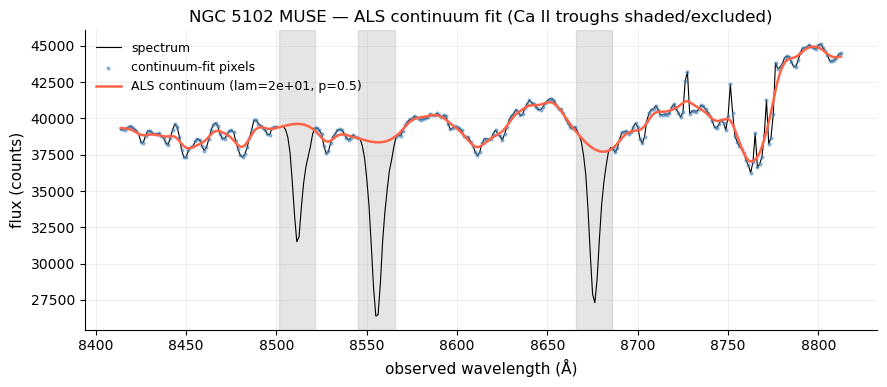

In [4]:
# Fixed hyperparameters -- no search, chosen once by inspecting the plot below.
LAM = 15
P   = 0.5

continuum = asymmetric_least_squares_continuum(f, base_mask=base_mask, lam=LAM, p=P, niter=15)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(w, f, lw=0.8, color='black', label='spectrum')
ax.scatter(w[base_mask], f[base_mask], s=4, color='steelblue', alpha=0.5,
           label='continuum-fit pixels', zorder=3)
ax.plot(w, continuum, lw=1.8, color='tomato', label=f'ALS continuum (lam={LAM:.0e}, p={P})', zorder=4)
for c in caii_centers_obs:
    ax.axvspan(c - CAII_HALF_WIDTH_A, c + CAII_HALF_WIDTH_A, color='grey', alpha=0.2, zorder=0)
ax.set_xlabel('observed wavelength (Å)')
ax.set_ylabel('flux (counts)')
ax.set_title('NGC 5102 MUSE — ALS continuum fit (Ca II troughs shaded/excluded)')
ax.legend(fontsize=9, framealpha=1.0, facecolor='white')
plt.tight_layout()
plt.show()

## 4. Divide out the continuum and save a `.norm` file

Divide the flux (and its error) by the fitted continuum, then write a `.norm` file
(`wavelength normflux normflux_err` -- see `kinextract.io.read_norm_spectrum`) that
`load_spectrum_for_fit` recognizes by its extension and reads directly in
pre-normalized mode.

wrote /var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/kinextract_prenorm_vvc1abg4/bin0105sp_manual.norm  (320 pixels)


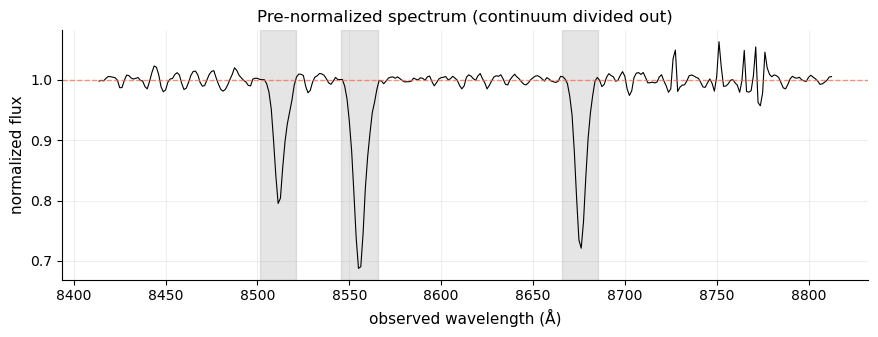

In [5]:
normflux     = f / continuum
normflux_err = fe / continuum

# Written to a system temp directory, not the notebook's own directory, so
# repeated runs don't leave stray files behind in the repo.
NORM_DIR  = Path(tempfile.mkdtemp(prefix='kinextract_prenorm_'))
NORM_FILE = NORM_DIR / 'bin0105sp_manual.norm'
np.savetxt(NORM_FILE, np.column_stack([w, normflux, normflux_err]), fmt='%14.6f')
print(f"wrote {NORM_FILE}  ({len(w)} pixels)")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(w, normflux, lw=0.8, color='black')
ax.axhline(1.0, lw=1.0, color='tomato', ls='--', alpha=0.7)
for c in caii_centers_obs:
    ax.axvspan(c - CAII_HALF_WIDTH_A, c + CAII_HALF_WIDTH_A, color='grey', alpha=0.2, zorder=0)
ax.set_xlabel('observed wavelength (Å)')
ax.set_ylabel('normalized flux')
ax.set_title('Pre-normalized spectrum (continuum divided out)')
plt.tight_layout()
plt.show()

# Part 2 — Fitting the pre-normalized spectrum (joint mode off)

## 5. FitConfig with `fit_continuum=False` and `joint_prenorm=False`

With the continuum already divided out, the fit needs nothing further from the
continuum-fitting machinery: `fit_continuum=False` fixes the model's continuum at 1.0
instead of co-fitting a P-spline, and `joint_prenorm=False` (the default) skips
`kinextract.joint` entirely, using the plain shipped non-parametric MAP path directly
-- joint mode fully off. `norm_wave_frame="observed"` tells kinextract our `.norm`
file's wavelength column is observed-frame (it applies the `zgal` shift itself);
`norm_error_mode="file"` uses the `normflux_err` column we wrote above instead of a
uniform error.

In [6]:
cfg = FitConfig(
    template_list_file    = str(MUSE_DIR / 'Tlist'),
    template_dir          = str(MUSE_DIR),
    step                  = STEP,
    wavefitmin            = 8400.0,        # Å  (rest-frame; kinextract applies zgal)
    wavefitmax            = 8750.0,        # Å
    zgal                  = ZGAL,
    losvd_vmin            = -300.0,        # km/s
    losvd_vmax            = +300.0,        # km/s
    fit_continuum         = False,         # <-- joint mode fully off: continuum fixed at 1.0
    joint_prenorm         = False,         # <-- and don't route through kinextract.joint either
    norm_wave_frame       = "observed",    # our .norm wavelength column is observed-frame
    norm_error_mode       = "file",        # use our normflux_err column
    xlam_auto             = True,
    xlam_criterion        = 'roughness',
    xlam_smooth_threshold = 0.25,
    sigl                  = 100.0,
    clean                 = True,
    map_maxiter           = 20000,
    print_every           = 10000,
)

fit = run_spectral_fit(cfg, gal_file=str(NORM_FILE))
st  = fit['state']
out = fit['outputs']
b   = out['b']
gp  = out['gp']
print(f"chi2_red = {out['chi2_red']:.3f}")
print(f"success  : {fit['result'].success}")
if not fit['result'].success:
    print(f"  WARNING: L-BFGS-B did not converge ({fit['result'].message}) -- treat "
          "V/sigma/h3/h4 as unreliable; consider raising map_maxiter or loosening map_ftol.")

chi2_red = 0.326
success  : True


## 6. Gauss-Hermite moments

In [7]:
gh = fit_losvd_gauss_hermite(st.xl, b, fit_h3h4=True)
print(f"V   = {gh['vherm']:+.1f} km/s")
print(f"sigma = {gh['sherm']:.1f} km/s")
print(f"h3  = {gh['h3']:+.4f}")
print(f"h4  = {gh['h4']:+.4f}")

V   = +24.7 km/s
sigma = 41.4 km/s
h3  = +0.0641
h4  = -0.0268


## 7. Diagnostic plots

`plot_continuum` is not useful here (`fit_continuum=False` means the fit has no
continuum of its own to show -- it's already been divided out); `plot_fit`/`plot_losvd`
are the relevant built-ins for a pre-normalized-mode fit like this one.

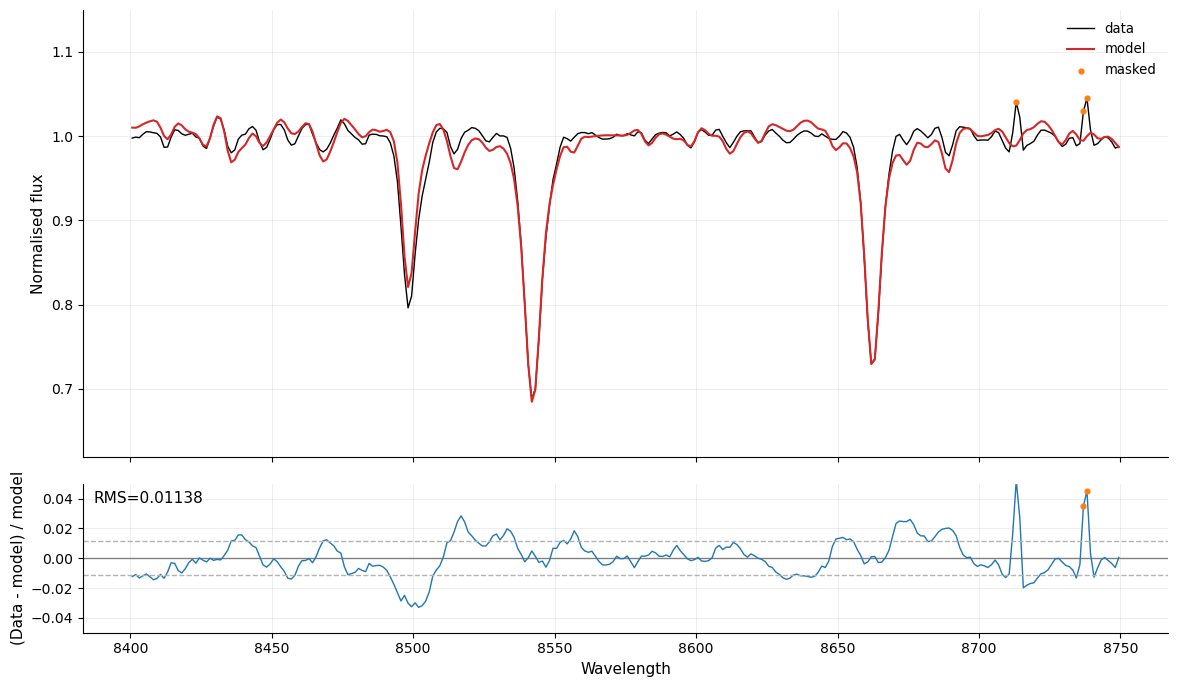

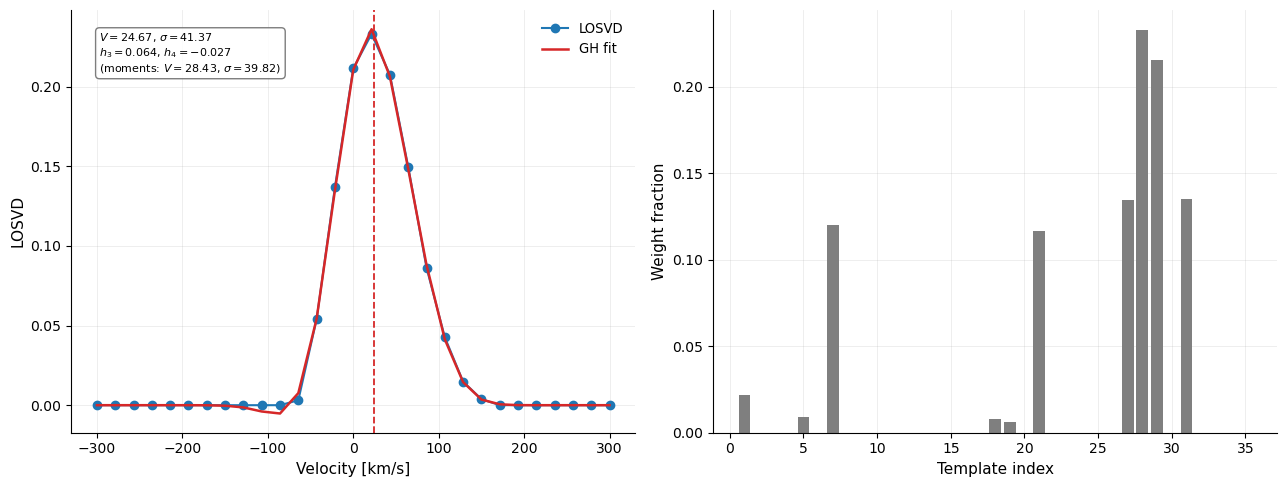

In [8]:
from kinextract.plotting import plot_fit, plot_losvd

plot_fit(fit)
plot_losvd(fit)

## 8. Summary

- The ALS math (`kinextract.continuum.asymmetric_least_squares_continuum`) is a
  standalone utility, not part of the main fitting pipeline -- it's useful exactly
  the way it's used here: a one-time, by-hand continuum estimate for a spectrum you
  intend to fit (possibly many times, e.g. via `LOSVDErrorEstimator.residual_bootstrap`)
  with the continuum fixed thereafter.
- Masking and `(lam, p)` are fixed by hand and checked visually, not searched -- a
  deliberate choice: the retired in-pipeline ALS hyperparameter search was found to
  systematically settle on an oversmoothed continuum on real data (see
  `kinextract.joint`'s module docstring), and a real one-time visual check avoids that
  failure mode entirely.
- Once normalized, `fit_continuum=False` and `joint_prenorm=False` together mean joint
  mode is fully off: the plain shipped non-parametric MAP path runs directly on the
  pre-normalized spectrum, with the continuum fixed at 1.0.
- If your own spectrum's continuum estimate has a residual offset (real ALS baselines
  are never pixel-perfect), consider dividing `normflux` by its own median over the
  continuum-fit pixels before saving -- the pre-normalized path has no floating
  continuum-offset term of its own to absorb such an offset.